Link dataset: https://www.kaggle.com/datasets/fedesoriano/traffic-prediction-dataset

Per questa analisi è stato scelto il Traffic Prediction Dataset. Il dataset originale è strutturato su quattro fetures principali: `ID` (identificativo univoco), `DateTime` (data e ora della misurazione), `Junction` (l'incrocio di riferimento) e `Vehicles` (il numero di veicoli transitati).

L'obiettivo del progetto è addestrare un modello di predizione in grado di stimare il volume di traffico (variabile target Vehicles). Attraverso l'elaborazione della data, il modello imparerà a prevedere l'intensità del traffico basandosi sulla posizione (lo specifico incrocio) e sulle variabili temporali (l'orario della giornata e la tipologia di giorno, ad esempio feriale o festivo).

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('archive/traffic.csv')
display(df.head(10))


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
5,2015-11-01 05:00:00,1,6,20151101051
6,2015-11-01 06:00:00,1,9,20151101061
7,2015-11-01 07:00:00,1,8,20151101071
8,2015-11-01 08:00:00,1,11,20151101081
9,2015-11-01 09:00:00,1,12,20151101091


Come si può notare dalle informazioni generali, il dataset include la variabile DateTime. Poiché i modelli di Machine Learning non sono in grado di elaborare direttamente date in formato testuale, è necessario applicare una trasformazione.
Procederemo dunque a scomporre la feature DataTime in alcune nuove features (`Year`, `Month`, `Day`, `Hour`, `DayOfWeek`).
Questo passaggio è fondamentale per permettere all'algoritmo di catturare i pattern ciclici del traffico, come ad esempio i picchi nelle ore di punta o le differenze di volume tra giorni feriali e festivi.

In [55]:


# Convertiamo la colonna DateTime in un formato che Python capisce
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek # 0=Lunedì, 6=Domenica

df.drop(columns=['DateTime'], inplace=True)

display(df.head(10))

,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,1,15,20151101001,2015,11,1,0,6
1,2,6,20151101002,2015,11,1,0,6
2,3,9,20151101003,2015,11,1,0,6
3,3,7,20151101013,2015,11,1,1,6
4,1,13,20151101011,2015,11,1,1,6
5,2,6,20151101012,2015,11,1,1,6
6,2,5,20151101022,2015,11,1,2,6
7,1,10,20151101021,2015,11,1,2,6
8,3,5,20151101023,2015,11,1,2,6
9,2,6,20151101032,2015,11,1,3,6


## Analisi Esplorativa dei Dati
In questa sezione analizziamo le caratteristiche principali del dataset per comprendere la distribuzione del traffico e le relazioni tra le variabili.
Iniziamo osservando le statistiche descrittive generali e i valori nulli.

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")

# Mostriamo le informazioni generali (tipi di dato e valori non nulli)
print("INFORMAZIONI GENERALI:")
df.info()

# Mostriamo le statistiche di base (media, deviazione standard, quartili)
print("\nSTATISTICHE DESCRITTIVE:")
display(df.describe())

# Contiamo i valori unici per capire la cardinalità delle variabili categoriche/intere
print("\nVALORI DISTINTI PER COLONNA:")
display(df.nunique())

INFORMAZIONI GENERALI:
<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Junction   48120 non-null  int64
 1   Vehicles   48120 non-null  int64
 2   ID         48120 non-null  int64
 3   Year       48120 non-null  int32
 4   Month      48120 non-null  int32
 5   Day        48120 non-null  int32
 6   Hour       48120 non-null  int32
 7   DayOfWeek  48120 non-null  int32
dtypes: int32(5), int64(3)
memory usage: 2.0 MB

STATISTICHE DESCRITTIVE:


,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
count,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000
mean,2.180549,22.791334,2.016330e+10,2016.269825,5.884289,15.700748,11.500000,2.996010
std,0.966955,20.750063,5.944854e+06,0.616093,3.569872,8.784073,6.922258,2.000017
min,1.000000,1.000000,2.015110e+10,2015.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,9.000000,2.016042e+10,2016.000000,3.000000,8.000000,5.750000,1.000000
50%,2.000000,15.000000,2.016093e+10,2016.000000,5.000000,16.000000,11.500000,3.000000
75%,3.000000,29.000000,2.017023e+10,2017.000000,9.000000,23.000000,17.250000,5.000000
max,4.000000,180.000000,2.017063e+10,2017.000000,12.000000,31.000000,23.000000,6.000000



VALORI DISTINTI PER COLONNA:


Junction         4
Vehicles       141
ID           48120
Year             3
Month           12
Day             31
Hour            24
DayOfWeek        7
dtype: int64

Come si può notare, il dataset ritrae il traffico su 4 incorci per ogni ora e per ogni giorno di ogni mese per 3 anni

### Distribuzione della Variabile Target
La variabile target è `Vehicles`, ovvero il numero di veicoli. Visualizziamo la sua distribuzione per capire se presenta asimmetrie o valori anomali.

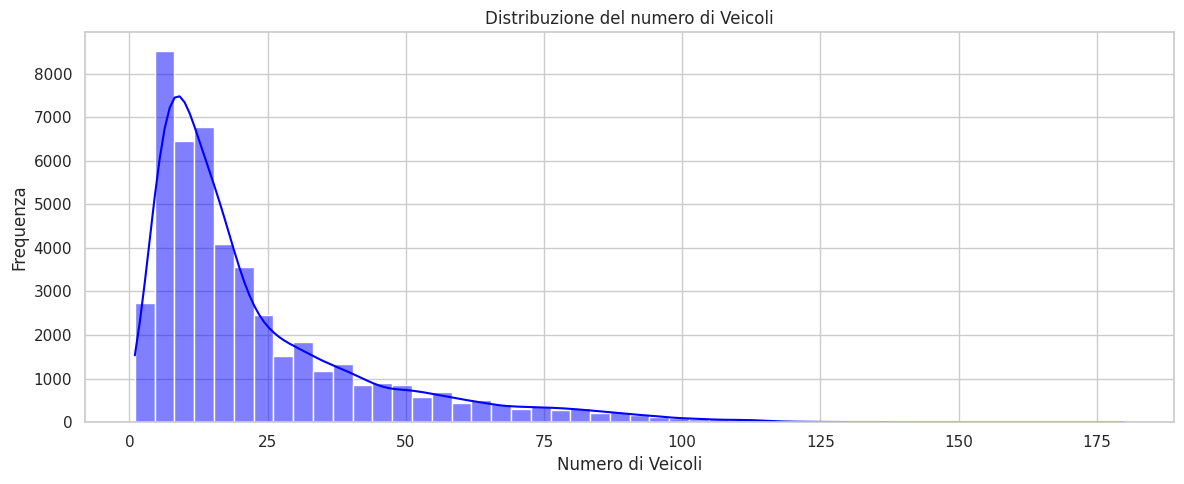

In [57]:
plt.figure(figsize=(12, 5))

# Istogramma
sns.histplot(df['Vehicles'], bins=50, kde=True, color='blue')
plt.title('Distribuzione del numero di Veicoli')
plt.xlabel('Numero di Veicoli')
plt.ylabel('Frequenza')

plt.tight_layout()
#plt.savefig('distribution_boxplot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

La variabile target Vehicles mostra una distribuzione fortemente asimmetrica a destra (right-skewed). La maggior parte dei dati si concentra tra 0 e 50 veicoli per ora. Questo indica che le situazioni di traffico "normale" sono la maggioranza.

### Analisi del Traffico nel Tempo e per Incrocio (Junction)
Verifichiamo come varia il volume di traffico in base agli incroci e alle ore del giorno.

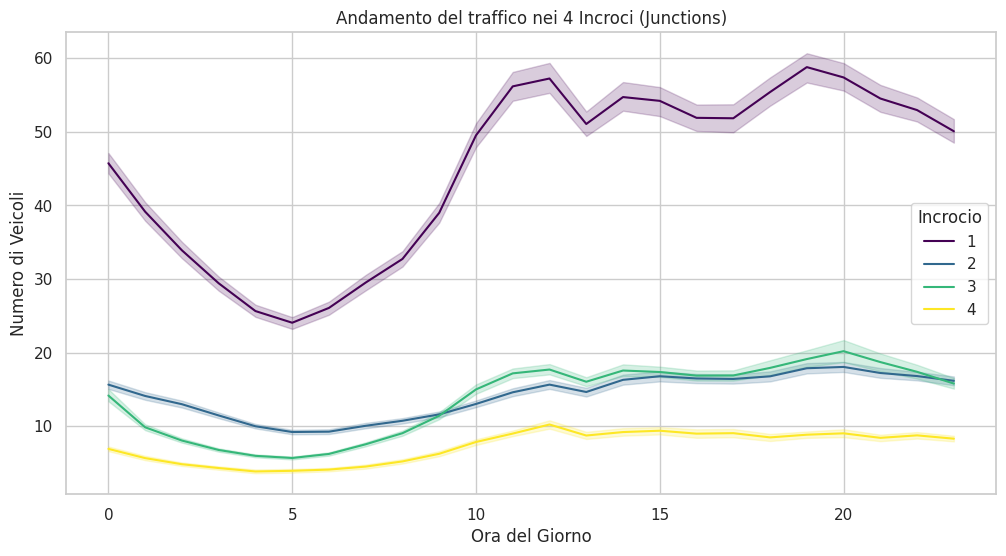

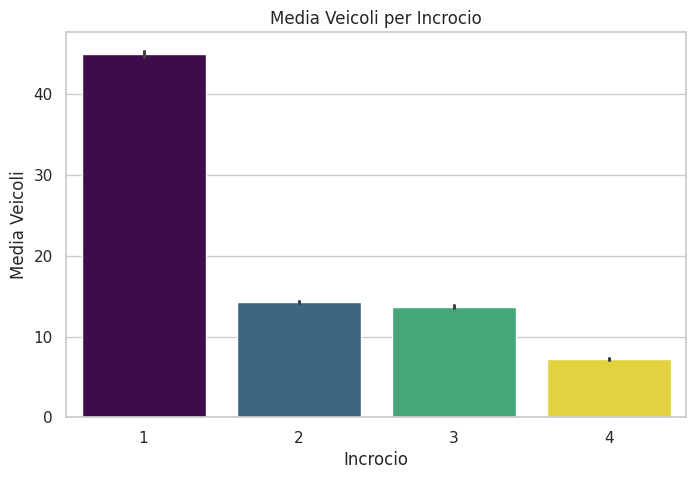

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Creiamo un grafico che mostra l'andamento dei veicoli nel tempo per ogni incrocio
sns.lineplot(data=df, x='Hour', y='Vehicles', hue='Junction', palette='viridis')

plt.title('Andamento del traffico nei 4 Incroci (Junctions)')
plt.xlabel('Ora del Giorno')
plt.ylabel('Numero di Veicoli')
plt.legend(title='Incrocio')
plt.show()

# Facciamo anche un grafico a barre per vedere la media di veicoli per incrocio
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Junction', y='Vehicles', hue="Junction", palette='viridis', legend=False)
#plt.xticks(x, df['Junction'].unique())
plt.title('Media Veicoli per Incrocio')
plt.xlabel('Incrocio')
plt.ylabel('Media Veicoli')
plt.show()

Si nota un evidente picco di traffico nelle ore serali [es. 18:00-19:00] e un calo notturno. L'incrocio 1 risulta essere costantemente il più trafficato

### Matrice di Correlazione
Infine, calcoliamo la correlazione di Pearson tra le variabili numeriche per individuare quali feature sono più linearmente legate al nostro target `Vehicles`.

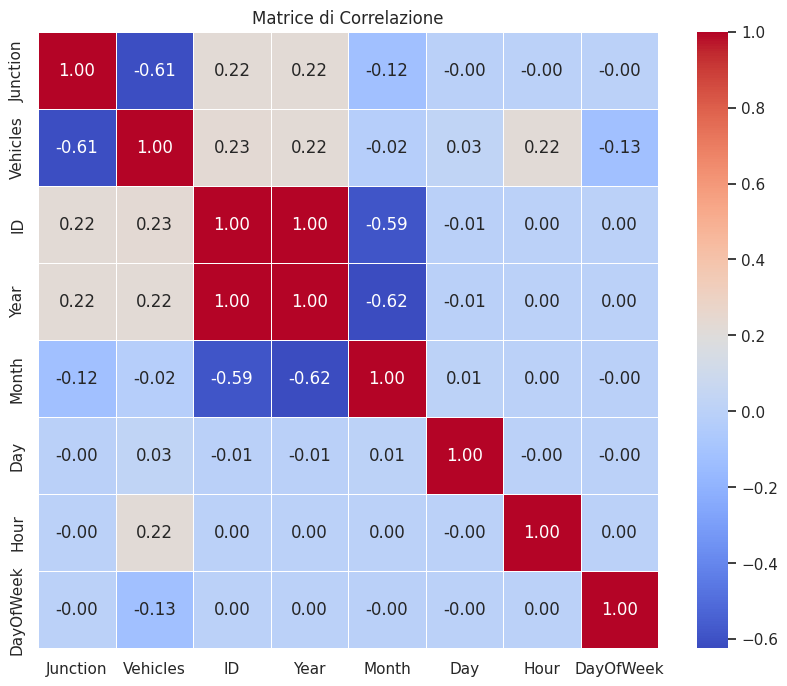

In [59]:
plt.figure(figsize=(10, 8))
# Calcoliamo la correlazione solo sulle colonne numeriche
corr_matrix = df.select_dtypes(include=['number']).corr()

# Disegniamo la heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice di Correlazione')
#plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

Esiste una forte correlazione negativa (-0.61) tra Junction e Vehicles. Questo conferma che la posizione è il fattore determinante: l'incrocio 1 è strutturalmente molto più trafficato degli altri.

Si nota una correlazione positiva con l'anno (0.22), suggerendo un trend di crescita del traffico nel tempo, e con l'ora (0.20), confermando l'importanza dei cicli giornalieri.

## PREPARAZIONE DATI



Sulla base dell'analisi esplorativa e delle linee guida del progetto, si è proceduto a una prima scrematura delle variabili:

* **Rimozione di `ID`:** Come suggerito dal Punto 1 delle linee guida, la colonna `ID` è stata eliminata in quanto identificatore univoco. Non contenendo alcuna informazione legata ai pattern di traffico, non ha alcun potere predittivo.

* **Rimozione di `Day` e `Month`:** L'analisi della matrice di correlazione ha evidenziato che queste due variabili hanno un impatto quasi nullo sulla variabile target `Vehicles` (correlazione rispettivamente di -0.02 e 0.03). Si è quindi deciso di scartarle per ridurre il "rumore" nei dati, semplificando il modello senza comprometterne la precisione predittiva.

In [60]:
df_final = df.drop(['Day','Month','ID'], axis=1)

display(df_final.head(10))

,Junction,Vehicles,Year,Hour,DayOfWeek
0,1,15,2015,0,6
1,2,6,2015,0,6
2,3,9,2015,0,6
3,3,7,2015,1,6
4,1,13,2015,1,6
5,2,6,2015,1,6
6,2,5,2015,2,6
7,1,10,2015,2,6
8,3,5,2015,2,6
9,2,6,2015,3,6


## PREPARAIONE DEI MODELLI

In [61]:
# 1. Definiamo X e y
X = df_final.drop(['Vehicles'], axis=1)
y = df_final['Vehicles']

# 2. Calcoliamo l'indice per lo split cronologico (80% train, 20% test)
n = len(df_final)
train_index = int(n * 0.8)

# 3. Creiamo i set di Training e Test
X_train = X.iloc[:train_index]
y_train = y.iloc[:train_index]
X_test = X.iloc[train_index:]
y_test = y.iloc[train_index:]

print(f"--- SPLIT CRONOLOGICO EFFETTUATO ---")
print(f"Dati di Allenamento (80%): {X_train.shape[0]} righe")
print(f"Dati di Test (20%): {X_test.shape[0]} righe")

# Verifica rapida: l'ultima riga del train deve venire prima della prima del test
print(f"\nUltimo indice Training: {X_train.index[-1]}")
print(f"Primo indice Test: {X_test.index[0]}")

--- SPLIT CRONOLOGICO EFFETTUATO ---
Dati di Allenamento (80%): 38496 righe
Dati di Test (20%): 9624 righe

Ultimo indice Training: 38495
Primo indice Test: 38496


Per garantire che il modello impari a interpretare i pattern nei dati con capacità di generalizzazione, senza limitarsi a "imparare a memoria" i valori storici (evitando così il rischio di *overfitting*), il dataset è stato suddiviso in due sottoinsiemi distinti:

1. **Training Set (80%):** per l'addestramento dei modelli e la ricerca degli iperparametri.

2. **Test Set (20%):** set isolato utilizzato solo alla fine per valutare le performance.

Poiché stiamo lavorando con dati sequenziali (il traffico nel tempo), durante la ricerca degli iperparametri (Randomized Search) non è stata utilizzata la classica K-Fold Cross Validation (che mischierebbe casualmente passato e futuro), ma una **Time Series Cross-Validation**. Questo assicura che il modello venga sempre validato su dati temporalmente successivi a quelli di training.

# I MODELLI

In [62]:
dizionario = {}

#metodo per valutare i modelli (MAE, R² e pearson coeff)
def model_evaluation(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    re = r2_score(y_true, y_pred)
    coeff,p_value = pearsonr(y_true, y_pred)
    mean_y = np.mean(y_true)
    errore_relativo = (mae / mean_y) * 100

    dizionario[model_name] = {'MAE': mae, 'R2': re, 'Pearson': coeff, 'Errore Relativo': errore_relativo}

    print(f"--- Risultati {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {re:.2f}")
    print(f"Pearson Coeff: {coeff:.2f}")
    print(f"Errore Relativo: {errore_relativo:.2f}%")

### LINEAR REGRESSION

In [63]:
from sklearn.linear_model import LinearRegression


# 1. Creiamo l'istanza del modello
lin_reg = LinearRegression()

# 2. ALLENAMENTO (Fit)
lin_reg.fit(X_train, y_train)

# 3. TEST (Esame)
y_pred_lin = lin_reg.predict(X_test)

#4. STAMPA RISULTATI
print(f"i pesi applicati a junction, year, month, day, hour, dayofweek: {lin_reg.coef_} e l'intercetta: {lin_reg.intercept_}")
model_evaluation("Regressione Lineare", y_test, y_pred_lin)

i pesi applicati a junction, year, month, day, hour, dayofweek: [-13.44982919  10.69731386   0.60391598  -1.15629321] e l'intercetta: -21520.77632737379
--- Risultati Regressione Lineare ---
MAE: 10.93
R²: 0.60
Pearson Coeff: 0.82
Errore Relativo: 37.33%


### RANDOM FOREST

In [64]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=1000, #1000 alberi nella foresta
    max_depth=15,
    random_state=42, # rende i risultati riproducibili CIT. GUIDA GALATTICA PER AUTOSTOPPISTI
    min_samples_leaf=5, # Ogni foglia deve avere almeno 5 campioni (riduce overfitting)
    n_jobs=-1 # n_jobs=-1 serve a usare tutti i core
)

# 2. ALLENAMENTO
rf_model.fit(X_train, y_train)

# 3. TEST
y_pred_rf = rf_model.predict(X_test)

#4. STAMPA RISULTATI
model_evaluation("Random Forest", y_test, y_pred_rf)

--- Risultati Random Forest ---
MAE: 5.65
R²: 0.90
Pearson Coeff: 0.96
Errore Relativo: 19.30%


### XGBOOST

In [65]:
from xgboost import XGBRegressor

# 1. Creiamo il modello XGBoost
xgb_model = XGBRegressor(n_estimators=1000, #   n_estimators=1000 (numero di alberi)
    learning_rate=0.01, #passi che il modello fa per correggere gli errori
    max_depth=8, #nodi massimi per albero
    subsample=0.8, #   subsample=0.8 (ogni albero vede solo l'80% dei dati) cosi da evitare overfitting
    random_state=42,
    n_jobs=-1
)

# 2. ALLENAMENTO
xgb_model.fit(X_train, y_train)

# 3. TEST
y_pred_xgb = xgb_model.predict(X_test)

#4. STAMPA RISULTATI
model_evaluation("XGBoost", y_test, y_pred_xgb)

--- Risultati XGBoost ---
MAE: 5.64
R²: 0.90
Pearson Coeff: 0.96
Errore Relativo: 19.25%


### LIGHTGBM

In [66]:
from lightgbm import LGBMRegressor

# 1. Configurazione del modello
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=50, #numero di foglie totali per albero
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 2. Allenamento
lgb_model.fit(X_train, y_train)

# 3. Predizione
y_pred_lgb = lgb_model.predict(X_test)

# 4. Valutazione
model_evaluation("LightGBM", y_test, y_pred_lgb)

--- Risultati LightGBM ---
MAE: 5.62
R²: 0.90
Pearson Coeff: 0.96
Errore Relativo: 19.19%


### KNN

In [67]:
from sklearn.neighbors import KNeighborsRegressor

# Utilizzo uno scaler per normalizzare i dati in mdo che i modelli non vengano influenzati da scale diverse tra le variabili

# 1. Configurazione del modello
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=20, n_jobs=-1)
)

# 2. Allenamento
knn_model.fit(X_train, y_train)

# 3. Predizione
y_pred_knn = knn_model.predict(X_test)

# 4. Valutazione
model_evaluation("K-Nearest Neighbors", y_test, y_pred_knn)

--- Risultati K-Nearest Neighbors ---
MAE: 5.91
R²: 0.89
Pearson Coeff: 0.96
Errore Relativo: 20.17%


### MLP

In [68]:
from sklearn.neural_network import MLPRegressor

# 1. Configurazione del modello
mlp_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(100, 50), # due strati: uno da 100 hidden layers e uno da 50
        activation='relu', #Se il segnale che arriva al neurone è negativo, lo azzera; se è positivo, lo lascia passare
        solver='adam',
        max_iter=500,
        random_state=42
    )
)

# 2. Allenamento
mlp_model.fit(X_train, y_train)

# 3. Predizione
y_pred_mlp = mlp_model.predict(X_test)

# 4. Valutazione
model_evaluation("Multi-Layer Perceptron", y_test, y_pred_mlp)

--- Risultati Multi-Layer Perceptron ---
MAE: 5.55
R²: 0.90
Pearson Coeff: 0.96
Errore Relativo: 18.94%


### SVR

In [69]:
from sklearn.svm import SVR

# 1. Configurazione del modello
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf',
        C=100,
        epsilon=0.1,
        cache_size=1000
    )
)

# 2. Allenamento
print("Inizio allenamento SVR...")
svr_model.fit(X_train, y_train)

# 3. Predizione
y_pred_svr = svr_model.predict(X_test)

# 4. Valutazione
model_evaluation("Support Vector Regression", y_test, y_pred_svr)

Inizio allenamento SVR...
--- Risultati Support Vector Regression ---
MAE: 5.79
R²: 0.89
Pearson Coeff: 0.96
Errore Relativo: 19.76%


# **GRAFICI DEI MODELLI**

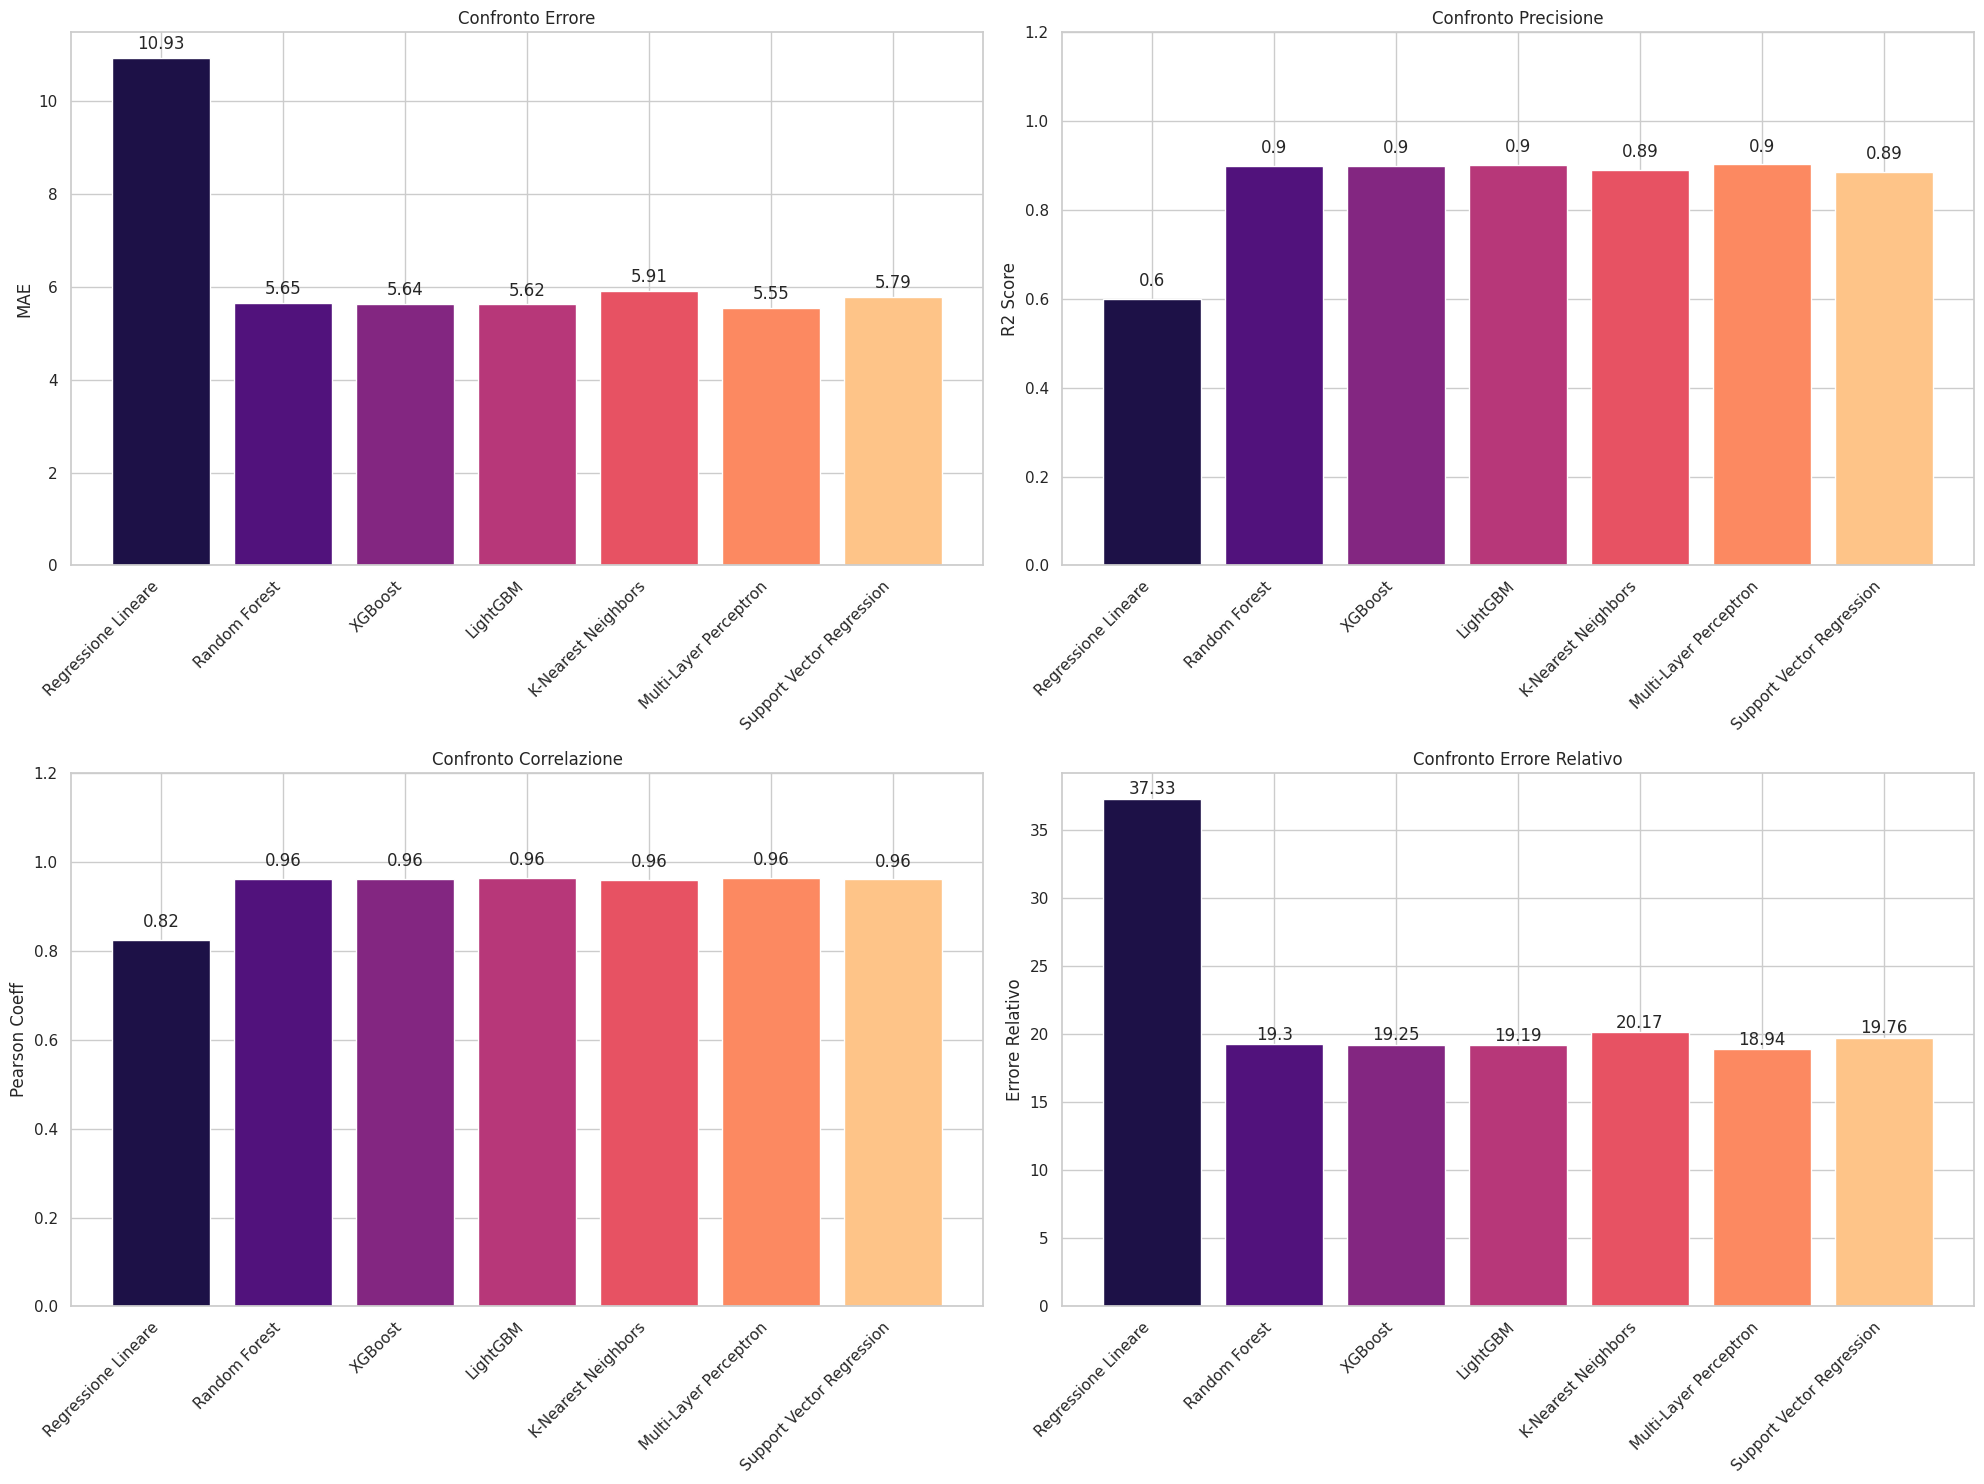

In [70]:
df_results = pd.DataFrame(dizionario).T
df_7 = df_results.head(7)
modelli = df_7.index
mae_values = df_7['MAE']
r2_values = df_7['R2']
coeff_values = df_7['Pearson']
err_rel_values = df_7['Errore Relativo']

x = np.arange(len(modelli))
colori = sns.color_palette("magma", len(modelli))
plt.figure(figsize=(20, 15))
# 1. Grafico per il MAE
plt.subplot(2, 2, 1)
bars1 = plt.bar(x, mae_values, color=colori)
plt.xticks(x, modelli, rotation=45, ha='right')
plt.ylabel('MAE')
plt.title('Confronto Errore')
# Aggiunge i numeri sopra le barre
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')

# 2. Grafico per R2
plt.subplot(2, 2, 2)
bars2 = plt.bar(x, r2_values, color=colori)
plt.xticks(x, modelli, rotation=45, ha='right')
plt.ylabel('R2 Score')
plt.title('Confronto Precisione')
plt.ylim(0, 1.2)
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')

# 3. Grafico per il coefficiente di Pearson
plt.subplot(2, 2, 3)
bars3 = plt.bar(x, coeff_values, color=colori)
plt.xticks(x, modelli, rotation=45, ha='right')
plt.ylabel('Pearson Coeff')
plt.title('Confronto Correlazione')
plt.ylim(0, 1.2)
for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')

# 4. Grafico per l'errore relativo
plt.subplot(2, 2, 4)
bars4 = plt.bar(x, err_rel_values, color=colori)
plt.xticks(x, modelli, rotation=45, ha='right')
plt.ylabel('Errore Relativo')
plt.title('Confronto Errore Relativo')
for bar in bars4:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
#plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Analisi Comparativa dei Modelli e Selezione del Modello Finale

I grafici sopra riportati mettono a confronto le performance dei sette modelli testati secondo la **precisione predittiva** (MAE, R², Pearson, Errore Relativo)

#### Analisi delle Performance
Dall'osservazione dei grafici riassuntivi, il primo dato evidente è l'inadeguatezza della Regressione Lineare. Con un Errore Assoluto Medio (MAE) di 10.93, un R² di appena 0.6 e un Errore Relativo che sfiora il 37%, risulta chiaro che la relazione tra le variabili temporali/spaziali e il volume di traffico non è lineare.
Passando ai modelli non lineari e di Ensemble (Random Forest, XGBoost, LightGBM) e alle Reti Neurali (MLP), si nota un drastico salto di qualità. Tutti questi modelli riescono a catturare la complessità dei dati in modo eccellente, attestandosi su prestazioni quasi identiche: un MAE dimezzato (intorno a 5.6 - 5.9), una precisione R² di 0.90 e una correlazione di Pearson pari a 0.96. Questo indica che i modelli spiegano il 90% della varianza del traffico stradale, un risultato ottimo.

#### Scelta del Modello di Riferimento: XGBoost
È stato scelto **XGBoost** come modello di riferimento per la fase finale di ottimizzazione. La scelta è giustificata dalla sua eccellente capacità di gestione degli *outliers* (precedentemente individuati nell'analisi esplorativa) e dalla stabilità dei risultati su tutte le metriche di errore e correlazione.

## XGBOOST OTTIMIZZATO CON RANDOMIZED SEARCH

In [71]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# 1. Inizializza il modello base
xgb_model = XGBRegressor(random_state=42)

# 2. Definisci il dizionario dei parametri da esplorare
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# 3. Creiamo il validatore speciale per le Serie Temporali
tscv = TimeSeriesSplit(n_splits=3)

# 3. Configura la Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=50,          # Numero di combinazioni casuali da provare 
    scoring='r2',       # Metrica di valutazione
    cv=tscv,            # Cross-validation temporale
    verbose=2,          # Stampa l'avanzamento
    random_state=42,
    n_jobs=-1
)

# 4. Avvia l'addestramento
print("Avvio della Randomized Search...")
random_search.fit(X_train, y_train)

# 5. Stampa i risultati
print("\nOttimizzazione completata!")
print("I migliori parametri trovati sono:")
print(random_search.best_params_)

# Puoi salvare automaticamente il modello migliore per fare predizioni
xgb_model_ott = random_search.best_estimator_


Avvio della Randomized Search...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=1

Per l'ottimizzazione degli iperparametri del modello XGBoost ho scelto di utilizzare la **Randomized Search**. Data l'elevata quantità di iperparametri di questo algoritmo, una Grid Search esaustiva sarebbe risultata computazionalmente proibitiva. La Randomized Search mi ha permesso di esplorare uno spazio di parametri molto ampio tenendo sotto controllo i tempi di calcolo.

Ho usato la *Time Series Cross Validation* integrata nella Randomized Search. Questo metodo crea dei validation set dinamici rispettando l'ordine temporale, permettendomi di massimizzare i dati di addestramento senza rischiare l'overfitting.

In [72]:
# 1. Predizione con il modello ottimizzato
y_pred_xgb = xgb_model_ott.predict(X_test)

#4. STAMPA RISULTATI
model_evaluation("XGBoost_Ottimizzato", y_test, y_pred_xgb)

--- Risultati XGBoost_Ottimizzato ---
MAE: 5.66
R²: 0.90
Pearson Coeff: 0.96
Errore Relativo: 19.32%


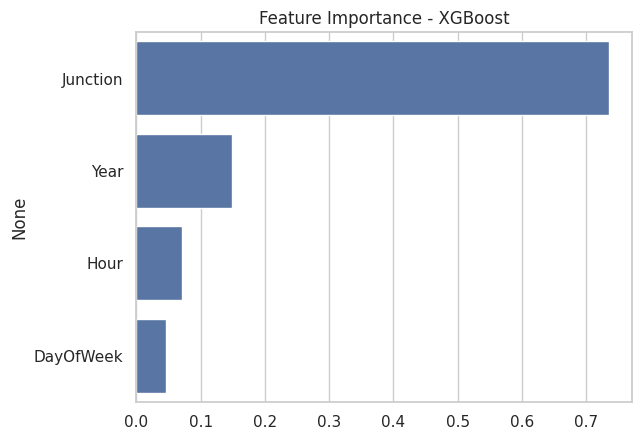

In [73]:
feature_importances = xgb_model_ott.feature_importances_
sns.barplot(x=feature_importances, y=X_train.columns)
plt.title("Feature Importance - XGBoost")
plt.show()

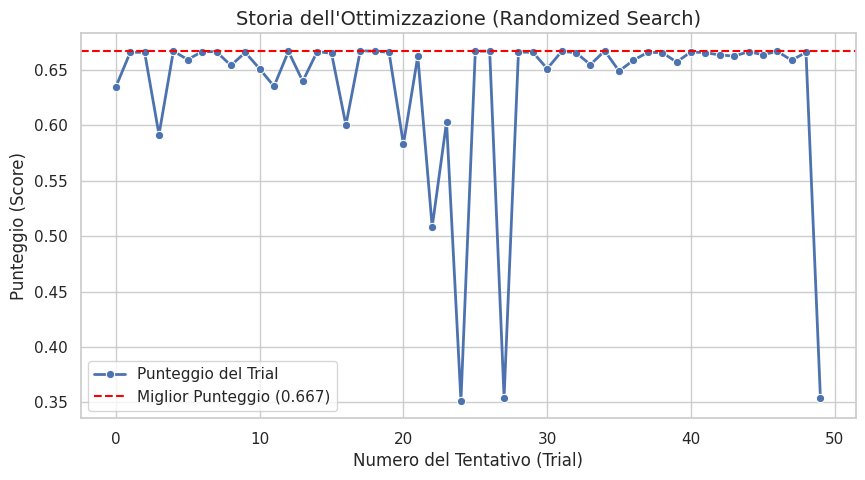

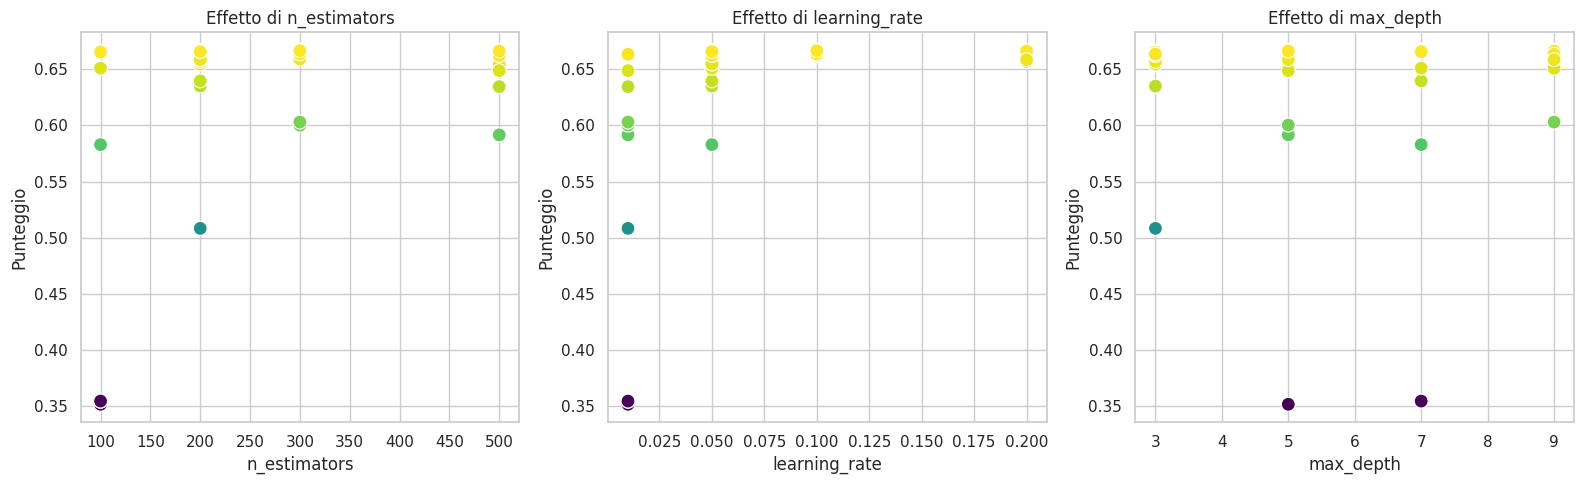

In [74]:
# 1. Estraiamo tutti i risultati dei tentativi in un comodo DataFrame
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results['Score'] = cv_results['mean_test_score']


# GRAFICO 1: Storia dell'Ottimizzazione
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Plottiamo l'andamento dei tentativi
sns.lineplot(x=cv_results.index, y=cv_results['Score'], marker='o', linewidth=2, label='Punteggio del Trial')

# Evidenziamo il miglior punteggio raggiunto
best_score = cv_results['Score'].max()
plt.axhline(best_score, color='red', linestyle='--', label=f'Miglior Punteggio ({best_score:.3f})')

plt.title("Storia dell'Ottimizzazione (Randomized Search)", fontsize=14)
plt.xlabel("Numero del Tentativo (Trial)")
plt.ylabel("Punteggio (Score)")
plt.legend()
plt.show()

# GRAFICO 2: Effetto dei Parametri
parametri_cercati = ['param_n_estimators', 'param_learning_rate', 'param_max_depth']

plt.figure(figsize=(16, 5))

# Creiamo un subplot per ogni parametro
for i, parametro in enumerate(parametri_cercati):
    plt.subplot(1, len(parametri_cercati), i+1)
    
    sns.scatterplot(
        data=cv_results, 
        x=parametro, 
        y='Score', 
        hue='Score',        # Colora i punti in base al punteggio
        palette='viridis', 
        s=100               # Dimensione dei punti
    )
    

    nome_pulito = parametro.replace('param_', '')
    plt.title(f'Effetto di {nome_pulito}')
    plt.xlabel(nome_pulito)
    plt.ylabel('Punteggio')
    plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

Dal primo grafico possiamo osservare l'andamento esplorativo della Randomized Search. La linea rossa tratteggiata rappresenta l'ottimo globale trovato all'interno dei tentativi effettuati, dimostrando come l'algoritmo abbia testato sia configurazioni sub-ottimali sia configurazioni molto performanti.

Il secondo grafico sostituisce la funzione di Parameter Importance. Invece di un semplice punteggio aggregato, ci permette di visualizzare direttamente la distribuzione dei risultati. Ad esempio, possiamo notare se i punteggi migliori (i punti più chiari) si concentrano verso valori alti o bassi di un determinato iperparametro, come la profondità dell'albero o il learning rate



# TREELITE

In [75]:
import treelite, tl2cgen
import os
import contextlib

# 1. Converto
booster = xgb_model_ott.get_booster()
tl_model = treelite.frontend.from_xgboost(booster)

tl2cgen.generate_c_code(
    tl_model,
    dirpath="./model_c_src",
    params={'parallel_comp': 4},
    verbose=False
)

# 2. Compila
with open(os.devnull, 'wb') as devnull:
    with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
        tl2cgen.export_lib(
            tl_model,
            toolchain="gcc",
            libpath="./xgb_model_ott.so",
            params={'parallel_comp': 4},
            verbose=False
        )


[18:32:46] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0
[18:32:46] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0


[18:32:46] /project/src/compiler/ast/split.cc:35: Parallel compilation enabled; member trees will be divided into 4 translation units.


## Compilazione del Modello con Treelite

Per poter utilizzare il modello predittivo all'interno di un'applicazione Web in tempo reale, si è scelto una **compilazione nativa in linguaggio C** tramite la libreria `treelite` e il generatore `tl2cgen`.

Questa operazione di ottimizzazione si divide in due fasi:

**1. Conversione e Generazione del Codice C**
Attraverso `treelite.frontend.from_xgboost`, l'albero decisionale addestrato viene prima astratto dalla libreria XGBoost e successivamente tradotto in puro codice sorgente C. Questo passaggio elimina tutto l'*overhead* e le dipendenze legate all'ambiente Python.

**2. Compilazione della Libreria Condivisa**
Tramite il compilatore di sistema (`gcc`), il codice C generato viene compilato in una libreria condivisa (`.so`).

# VALUTAZIONE DEI MODELLI

In [76]:
import time, os, tracemalloc, gc
from memory_profiler import memory_usage
from tqdm.notebook import tqdm

def tecno_evaluation(model_path, tecno_type):
    n_iters = 1000
    print(f"\n--- ANALISI COMPLETA: {tecno_type.upper()} (su {n_iters} iterazioni) ---")

    load_times = []
    load_peaks = []

    # --- 1. DIMENSIONE FILE ---
    file_size = os.path.getsize(model_path) / (1024 * 1024)
    
    # --- 2. TEMPO DI CARICAMENTO ---
    for n in tqdm(range(n_iters), desc="Analisi modello"):
        gc.collect()
        tracemalloc.start()
        start_load = time.perf_counter()

        m = tl2cgen.Predictor(model_path)

        load_times.append((time.perf_counter() - start_load) * 1000)
        _, peak_load_ram = tracemalloc.get_traced_memory()
        load_peaks.append(peak_load_ram / 1024)
        tracemalloc.stop()

        if n < n_iters - 1: del m
        else: model_obj = m

    # --- 3. PREDIZIONE ---
    x_input = tl2cgen.DMatrix(X_test.iloc[0:1].values.astype(np.float32))
    predict_fn = lambda: model_obj.predict(x_input)

    # --- 4. TEMPO DI ESECUZIONE ---
    inf_times = []
    for n in range(n_iters):
        t0 = time.perf_counter()
        predict_fn()
        inf_times.append((time.perf_counter() - t0) * 1000)

    # --- 5. USO RAM ---
    import psutil
    process = psutil.Process(os.getpid())
    ram_base = process.memory_info().rss / 1024
    def stress_test():
        for _ in range(n_iters): predict_fn()
    mem_use = memory_usage(stress_test, interval=0.01)
    peak_stress_ram = max(mem_use) * 1024
    delta_ram = max(0, peak_stress_ram - ram_base)

    # --- 6. OUTPUT REPORT ---
    print(f"Dimensione file: {file_size:.2f} MB")
    print(f"Tempo caricamento: {np.mean(load_times):.2f} ms (±{np.std(load_times):.2f} ms)")
    print(f"Latenza media: {np.mean(inf_times):.4f} ms (±{np.std(inf_times):.4f} ms)")
    print(f"Throughput: {1000/np.mean(inf_times):.2f} inf/sec")
    print(f"RAM Delta: {delta_ram:.2f} KB")
    print(f"RAM Picco: {np.mean(load_peaks):.2f} KB")



In [77]:
tecno_evaluation("xgb_model_ott.so", "treelite")


--- ANALISI COMPLETA: TREELITE (su 1000 iterazioni) ---


Analisi modello:   0%|          | 0/1000 [00:00<?, ?it/s]

Dimensione file: 1.47 MB
Tempo caricamento: 0.87 ms (±2.06 ms)
Latenza media: 0.0382 ms (±0.1734 ms)
Throughput: 26165.76 inf/sec
RAM Delta: 304.00 KB
RAM Picco: 3.18 KB


### Benchmarking delle Prestazioni

Per validare la scelta architetturale di convertire il modello in formato C tramite Treelite, è stato sviluppato uno script di valutazione. L'obiettivo è misurare l'efficienza computazionale del modello in condizioni simili a quelle di un ambiente di produzione reale.

**Metodologia di Test:**
Lo script esegue un test di stress su 1000 iterazioni (`n_iters = 1000`) per garantire la validità statistica delle metriche, neutralizzando eventuali fluttuazioni momentanee della CPU.

**Metriche Analizzate:**
1. **File Size (MB):** L'impatto sul disco della libreria condivisa.
2. **Tempo di Caricamento (Cold Start):** Il tempo necessario al server per caricare il modello in RAM.
3. **Latenza (ms):** Il tempo impiegato per effettuare una singola previsione (inferenza).
4. **Throughput (inf/sec):** Il numero massimo di previsioni che il sistema può gestire in un secondo.
5. **Memory Footprint (KB):** Il consumo reale e incrementale di RAM durante lo stress test, misurato isolando il processo Python.


# CONCLUSIONE


Il presente progetto ha coperto l'intero ciclo di vita di un sistema di Machine Learning, dall'analisi esplorativa dei dati (EDA) fino alla messa in produzione di un'applicazione web scalabile.

**Risultati Ottenuti**:

*Analisi Predittiva*:
I modelli di Ensemble Learning, in particolare XGBoost, hanno dimostrato una capacità superiore nel catturare le dinamiche non lineari del traffico urbano, raggiungendo un R² di 0.90 e un errore medio (MAE) contenuto.

*Ottimizzazione*:
La fase di Hyperparameter Tuning efettuarata con la tecnica **randomized search** ha confermato la stabilità del modello, migliorando gli iperparametri per ottenere l'efficienza migliore per il modello XGBoost in relazione alla stima del trafico.

Oltre all'accuratezza statistica, il progetto ha ottenuto anche *efficienza computazionale*. La conversione del modello XGBoost in codice C nativo, effettuata tramite la libreria Treelite, ha permesso di abbattere drasticamente i tempi di inferenza e l'impronta in memoria (RAM). L'integrazione di questo eseguibile all'interno di un'architettura web basata su Flask ha dimostrato la fattibilità di un sistema di monitoraggio leggero, scalabile e interrogabile in tempo reale.
